<a href="https://colab.research.google.com/github/Nicolas20Torres/Guia_1/blob/master/Relaci%C3%B3n_Minutos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT9nRHTMda7b7WjJrF59C4ILSaIpk-59ZK48A&s" width = "50%"  height="160
0">  </img>

# **Proyecto 1 – Relación Minutos Ingreso**
---

*Especializacion en Machine Learning*
> #### **Nombres:**
* *Mara Alejendra Calderón Diaz*
* *Julian David Mateus Laverde*
* *Nicolas Torres*
* *Milena Mariño*

---

# Evaluación del Comportamiento de los Clientes en una empresa de Telecomunicaciones

>La evaluación del comportamiento de los clientes en una empresa de telecomunicaciones permite entender patrones que pueden ser fundamentales para optimizar estrategias comerciales, de producto y de servicio al cliente. En este contexto, el análisis de las variables como los ingresos totales de los clientes (`totrev`) y el uso total de minutos (`totmou`) puede proporcionar información valiosa sobre cómo se comportan los clientes en relación con su nivel de ingresos y su uso de los servicios de la empresa.

## Objetivo del Estudio

El presente estudio se centra en la base de datos `Credito_dias.csv`, que incluye información detallada sobre el comportamiento de los clientes, como:

- **Ingresos totales del cliente** (`totrev`)
- **Total de minutos utilizados** (`totmou`)
- **Indicador de tarjeta de crédito** (`creditcd`)
- **Antigüedad del equipo actual** (`eqpdays`)

A través de este análisis, buscamos responder la siguiente pregunta: ¿Existe una relación significativa entre el total de minutos usados por los clientes y sus ingresos totales?

## Importancia del Análisis

Este tipo de preguntas resulta clave para definir estrategias de retención y adquisición de clientes. Por ejemplo, si encontramos que a mayor ingreso del cliente hay una mayor utilización de minutos, podría ser relevante enfocar promociones de mayor uso en clientes de ingresos altos. Por otro lado, si no existe tal relación, se podrían explorar otros factores que influencian el comportamiento del uso de servicios.

## Herramientas y Metodología

La programación y el análisis de datos nos permitirán abordar este problema desde una perspectiva cuantitativa, procesando grandes volúmenes de información que serían imposibles de analizar manualmente. De esta manera, se pretende extraer conclusiones objetivas que aporten a la toma de decisiones estratégicas de la empresa.



In [1]:
# Importar librerias a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import ttest_ind

In [2]:
# Cargar Dataset
df = pd.read_csv('https://checkpoint.url-protection.com/v1/url?o=https%3A//raw.githubusercontent.com/Izainea/seminario-de-programacion/master/Cuadernos/Clase%25202/Bases/Credito_dias.csv&g=YzAzYjg3N2JjOTk4NDdkNg==&h=YjViMmE1MGY4OWU0MDBlYTUzMWVmYjQzYTVhZTFhYTYyYmJkNmIwOTRkMDMxOTliMDU4MzRiM2YzYjI0NjI0ZA==&p=Y3AxZTp1bml2ZXJzaWRhZGVhbjpjOm86ZTk1MjQwYzc4NDhhZWY2YmYxYWVkNTFlY2MwMmNmNzg6djE6cDpU')
df.head()

,totmou,totrev,creditcd,eqpdays,Customer_ID
0,7269.0,906.58,Y,371,1082423
1,13552.0,1172.25,N,83,1069232
2,4152.0,577.39,Y,675,1031705
3,1863.0,294.26,Y,218,1089806
4,4155.0,433.16,N,222,1076695


In [3]:
# Revisar la información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   totmou       10000 non-null  float64
 1   totrev       10000 non-null  float64
 2   creditcd     9848 non-null   object 
 3   eqpdays      10000 non-null  int64  
 4   Customer_ID  10000 non-null  int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 390.8+ KB


In [4]:
# Definir como entera la valiable totmou
df['totmou']=df['totmou'].astype(int)
# Definir como categorica la creditcd
df['creditcd']=df['creditcd'].astype('category')
# Verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   totmou       10000 non-null  int64   
 1   totrev       10000 non-null  float64 
 2   creditcd     9848 non-null   category
 3   eqpdays      10000 non-null  int64   
 4   Customer_ID  10000 non-null  int64   
dtypes: category(1), float64(1), int64(3)
memory usage: 322.5 KB


### Conclusiones:
Se cuenta con una base de datos de 10000 registros con las variables ingresos totales del cliente, total de minutos utilizados, indicador de tarjeta de crédito y antigüedad del equipo actual. Asi, en resumen se cuenta con 3 variables tipo entero, 1 variable tipo categorica y 1 variable flotante.

# **Analisis Exploratorio**

* Incluyan un exploratorio separado por cada una de las variables que se tienen en esta base se sugiere que use histogramas para las variables numéricas y diagramas de barras para las categóricas.

## Valiable ingresos monetarios del cliente (`totrev`)

In [5]:
# Datos generales de la variable totrev
df['totrev'].describe()

,totrev
count,10000.000000
mean,1042.133807
std,857.144895
min,11.100000
25%,526.787500
50%,820.235000
75%,1272.975000
max,13426.600000


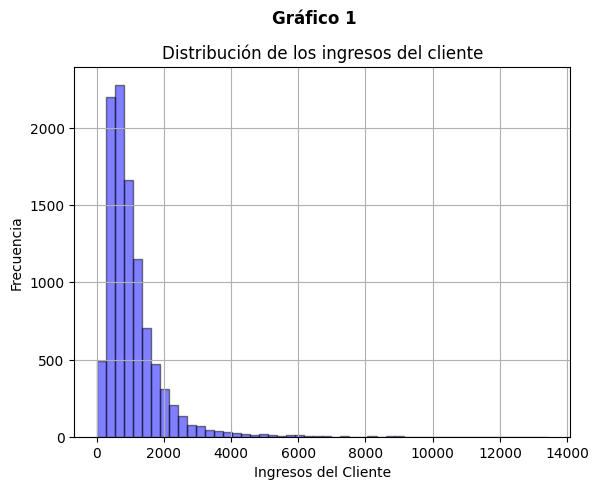

In [6]:
# Histograma variable totrev
plt.hist(df[['totrev']], bins=50, alpha=0.5, color='blue', edgecolor='black')
plt.xlabel('Ingresos del Cliente')
plt.ylabel('Frecuencia')
plt.title('Distribución de los ingresos del cliente')
plt.suptitle('Gráfico 1', fontweight='bold', y=1)
plt.grid()
plt.show()

#### Conclusiones variable (`totrev`):
Se tiene en promedio 1042.13 ingresos monetarios por cliente, la variable denota un sesgo positivo lo que significa que es la media es mayor que la mediana, es decir es más probable que los clientes hagan ingresos monetarios inferiores a 1042.13, igualmente significa que contamos con varios valores atípicos.

## Valiable Total de minutos utilizados (`totmou`)

In [7]:
df['totmou'].describe()

,totmou
count,10000.000000
mean,7692.803300
std,8657.910851
min,0.000000
25%,2576.000000
50%,5262.000000
75%,9823.250000
max,163264.000000


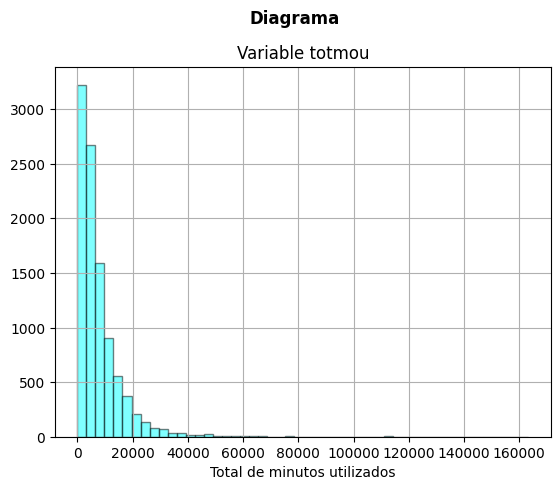

In [8]:
# Histograma variable totmou
plt.hist(df[['totmou']], bins=50, alpha=0.5, color='cyan', edgecolor='black')
plt.xlabel('Total de minutos utilizados')
plt.title('Variable totmou')
plt.suptitle('Diagrama', fontweight='bold', y=1)
plt.grid()
plt.show()

#### Conclusiones variable (`totmou`):
La variable totmou tiene una relación directa con correlación positiva

## Valiable Indicador de tarjeta de crédito (`creditcd`)

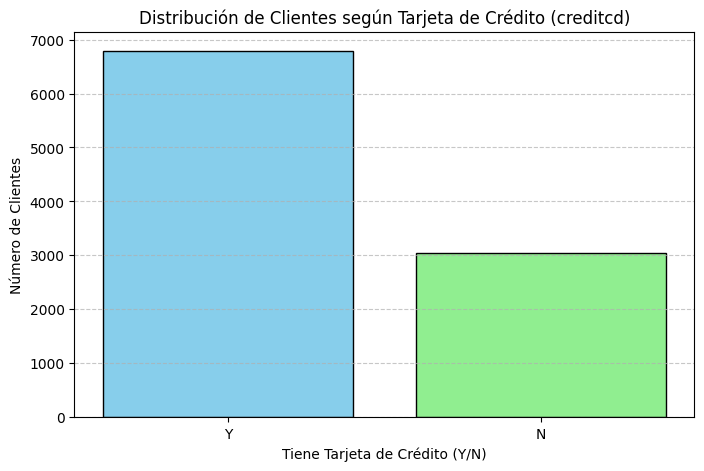

In [9]:


# Contar la frecuencia de cada categoría en la variable 'creditcd'
creditcd_counts = df['creditcd'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(creditcd_counts.index, creditcd_counts.values, color=['skyblue', 'lightgreen'], edgecolor='black')

# Añadir títulos y etiquetas
plt.title('Distribución de Clientes según Tarjeta de Crédito (creditcd)')
plt.xlabel('Tiene Tarjeta de Crédito (Y/N)')
plt.ylabel('Número de Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()


#### Conclusiones variable (`creditcd`):

Clientes con tarjeta de crédito :6,796 clientes tienen tarjeta
- Si los clientes con tarjeta de crédito representan la mayoría, se podría enfocar la estrategia en productos financieros más atractivos. En cambio, si los clientes sin tarjeta representan una porción relevante, podrían requerirse incentivos para su captación.

## Valiable Antigüedad del equipo actual (`eqpdays`)

count    10000.000000
mean       386.794500
std        252.720196
min         -5.000000
25%        210.000000
50%        338.000000
75%        522.000000
max       1823.000000
Name: eqpdays, dtype: float64


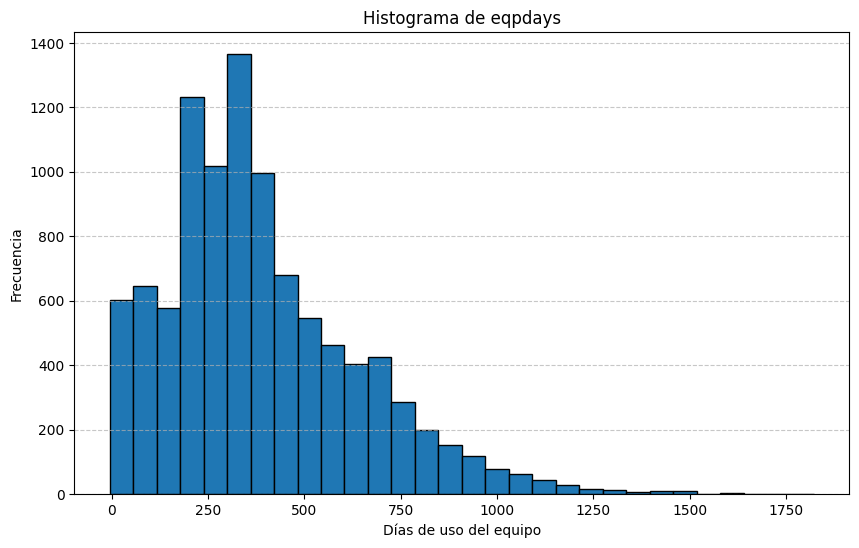

In [10]:
# Calcular estadísticas descriptivas de eqpdays
estadisticas_eqpdays = df['eqpdays'].describe()
print(estadisticas_eqpdays)
plt.figure(figsize=(10, 6))
plt.hist(df['eqpdays'], bins=30, edgecolor='black')
plt.title('Histograma de eqpdays')
plt.xlabel('Días de uso del equipo')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Conclusiones variable (`eqpdays`):

Nos permite observar la distribución de los días en los que los equipos estuvieron activos.
- las barras están concentradas hacia el lado izquierdo, significa que la mayoría de los equipos tuvieron pocos días de uso




# **Diagrama de dispersión entre las variables totrev y totmou**

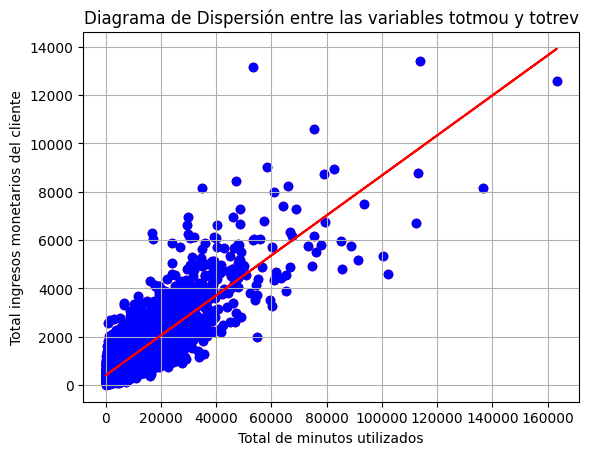

In [11]:
# Crear el diagrama de dispersión
plt.scatter(df['totmou'],df['totrev'],color='red' )
x = df['totmou']
y = df['totrev']
plt.scatter(x, y, color='blue', label='Datos')
# Calcular la línea de regresión
#Encuentra los coeficientes para la mejor línea ajustada (pendiente y ordenada al origen)
m, b = np.polyfit(x, y, 1)
# Graficar la línea de regresión
plt.plot(x, m*x + b, color='red', label=f'Regresión: y = {m:.2f}x + {b:.2f}')
# Añadir títulos y etiquetas
plt.title('Diagrama de Dispersión entre las variables totmou y totrev')
plt.xlabel('Total de minutos utilizados')
plt.ylabel('Total ingresos monetarios del cliente')
# Mostrar la gráfica
plt.grid()
plt.show()

Por medio de la grafica de dispersión se puede apreciar que la variable totmou
 y la variable totrev(los ingresos del cliente). Entre mas ingresos tienen los clientes mas minutos son consumidos.

# ¿Existe relación alguna entre el total de minutos usados con la compañía y el ingreso total de los clientes?

In [12]:
# Grafica de correlaciones
def correlation_plot(df, titulo,subtitulo):
    # Obtener las correlaciones
    corr = df.corr()

    # Definicion del tamaño de la grafica
    fig, axes = plt.subplots(len(df.columns), len(df.columns), figsize=(45, 30))

    # Agregar un título general a la figura
    fig.text(0.5, 1.03, subtitulo, ha='center', fontsize=120, fontweight='bold', style='italic')
    fig.suptitle(titulo, fontsize=80, y=0.98)

    # Recorrer todas las variables (para crear subplots)
    for i, col1 in enumerate(df.columns):
        for j, col2 in enumerate(df.columns):
            if i == j:
                # Histograma en la diagonal principal
                axes[i, j].hist(df[col1], bins=20, color='green', edgecolor='black')
                axes[i, j].set_title(f'{col1}', fontsize=10)
                axes[i, j].grid(True)
            elif i > j:
                # Gráfico de dispersión en la diagonal inferior
                axes[i, j].scatter(df[col2], df[col1], alpha=0.5, color='blue')
                # linea de tendencia
                m, b = np.polyfit(df[col2], df[col1], 1)
                axes[i, j].plot(df[col2], m * df[col2] + b, color='red', linestyle='-')
            else:
                # Mostrar burbuja basada en el coeficiente de correlación en la diagonal superior
                coef = np.corrcoef(df[col1], df[col2])[0][1]

                # Definir el tamaño de la burbuja
                bubble_size = np.abs(coef) * 30000

                # Dibujar la burbuja
                axes[i, j].scatter(10, 10, s=bubble_size, alpha=0.6, color='red')

                # Mostrar el valor del coeficiente dentro de la burbuja
                axes[i, j].text(10, 10, f'{coef:.2f}', ha='center', va='center', fontsize=30, color='black')

                # Ocultar los ejes
                axes[i, j].axis('off')  # Ocultar ejes en los coeficientes de correlación

            # Nombre de las columnas
            if i == 0:
                axes[i, j].set_title(col2, fontsize=25,rotation=90)

            # Nomre de las filas
            if j == 0:
                axes[i, j].set_ylabel(col1, fontsize=25, rotation=0, labelpad=40, ha='right')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.grid()
    plt.show()

* Analisis de correlacion de variables

Al aplicar esta gráfica a tu conjunto de datos, podrías obtener varias conclusiones importantes:

Relación entre totmouytotrev :

Es esperable que exista una compensación positiva entre el uso total y los ingresos totales. Un alto coeficiente indicaría que, a mayor uso del equipo, mayores ingresos se generan.
Influencia de los días activos ( eqpdays) :

Si eqpdaystiene una evaluación significativa con los ingresos ( totrev), podría sugerir que la duración de uso del equipo es un factor determinante para el ingreso generado.
Si la aceleración es baja, esto indicaría que los días activos no explican bien las variaciones en los ingresos.
Impacto de la tarjeta de crédito ( creditcd) :

Si se encontrara una valoración notable entre la variable creditcd(codificada como binaria) y otras variables como totrevo totmou, sugeriría que los clientes con tarjeta de crédito tenderán a consumir más.



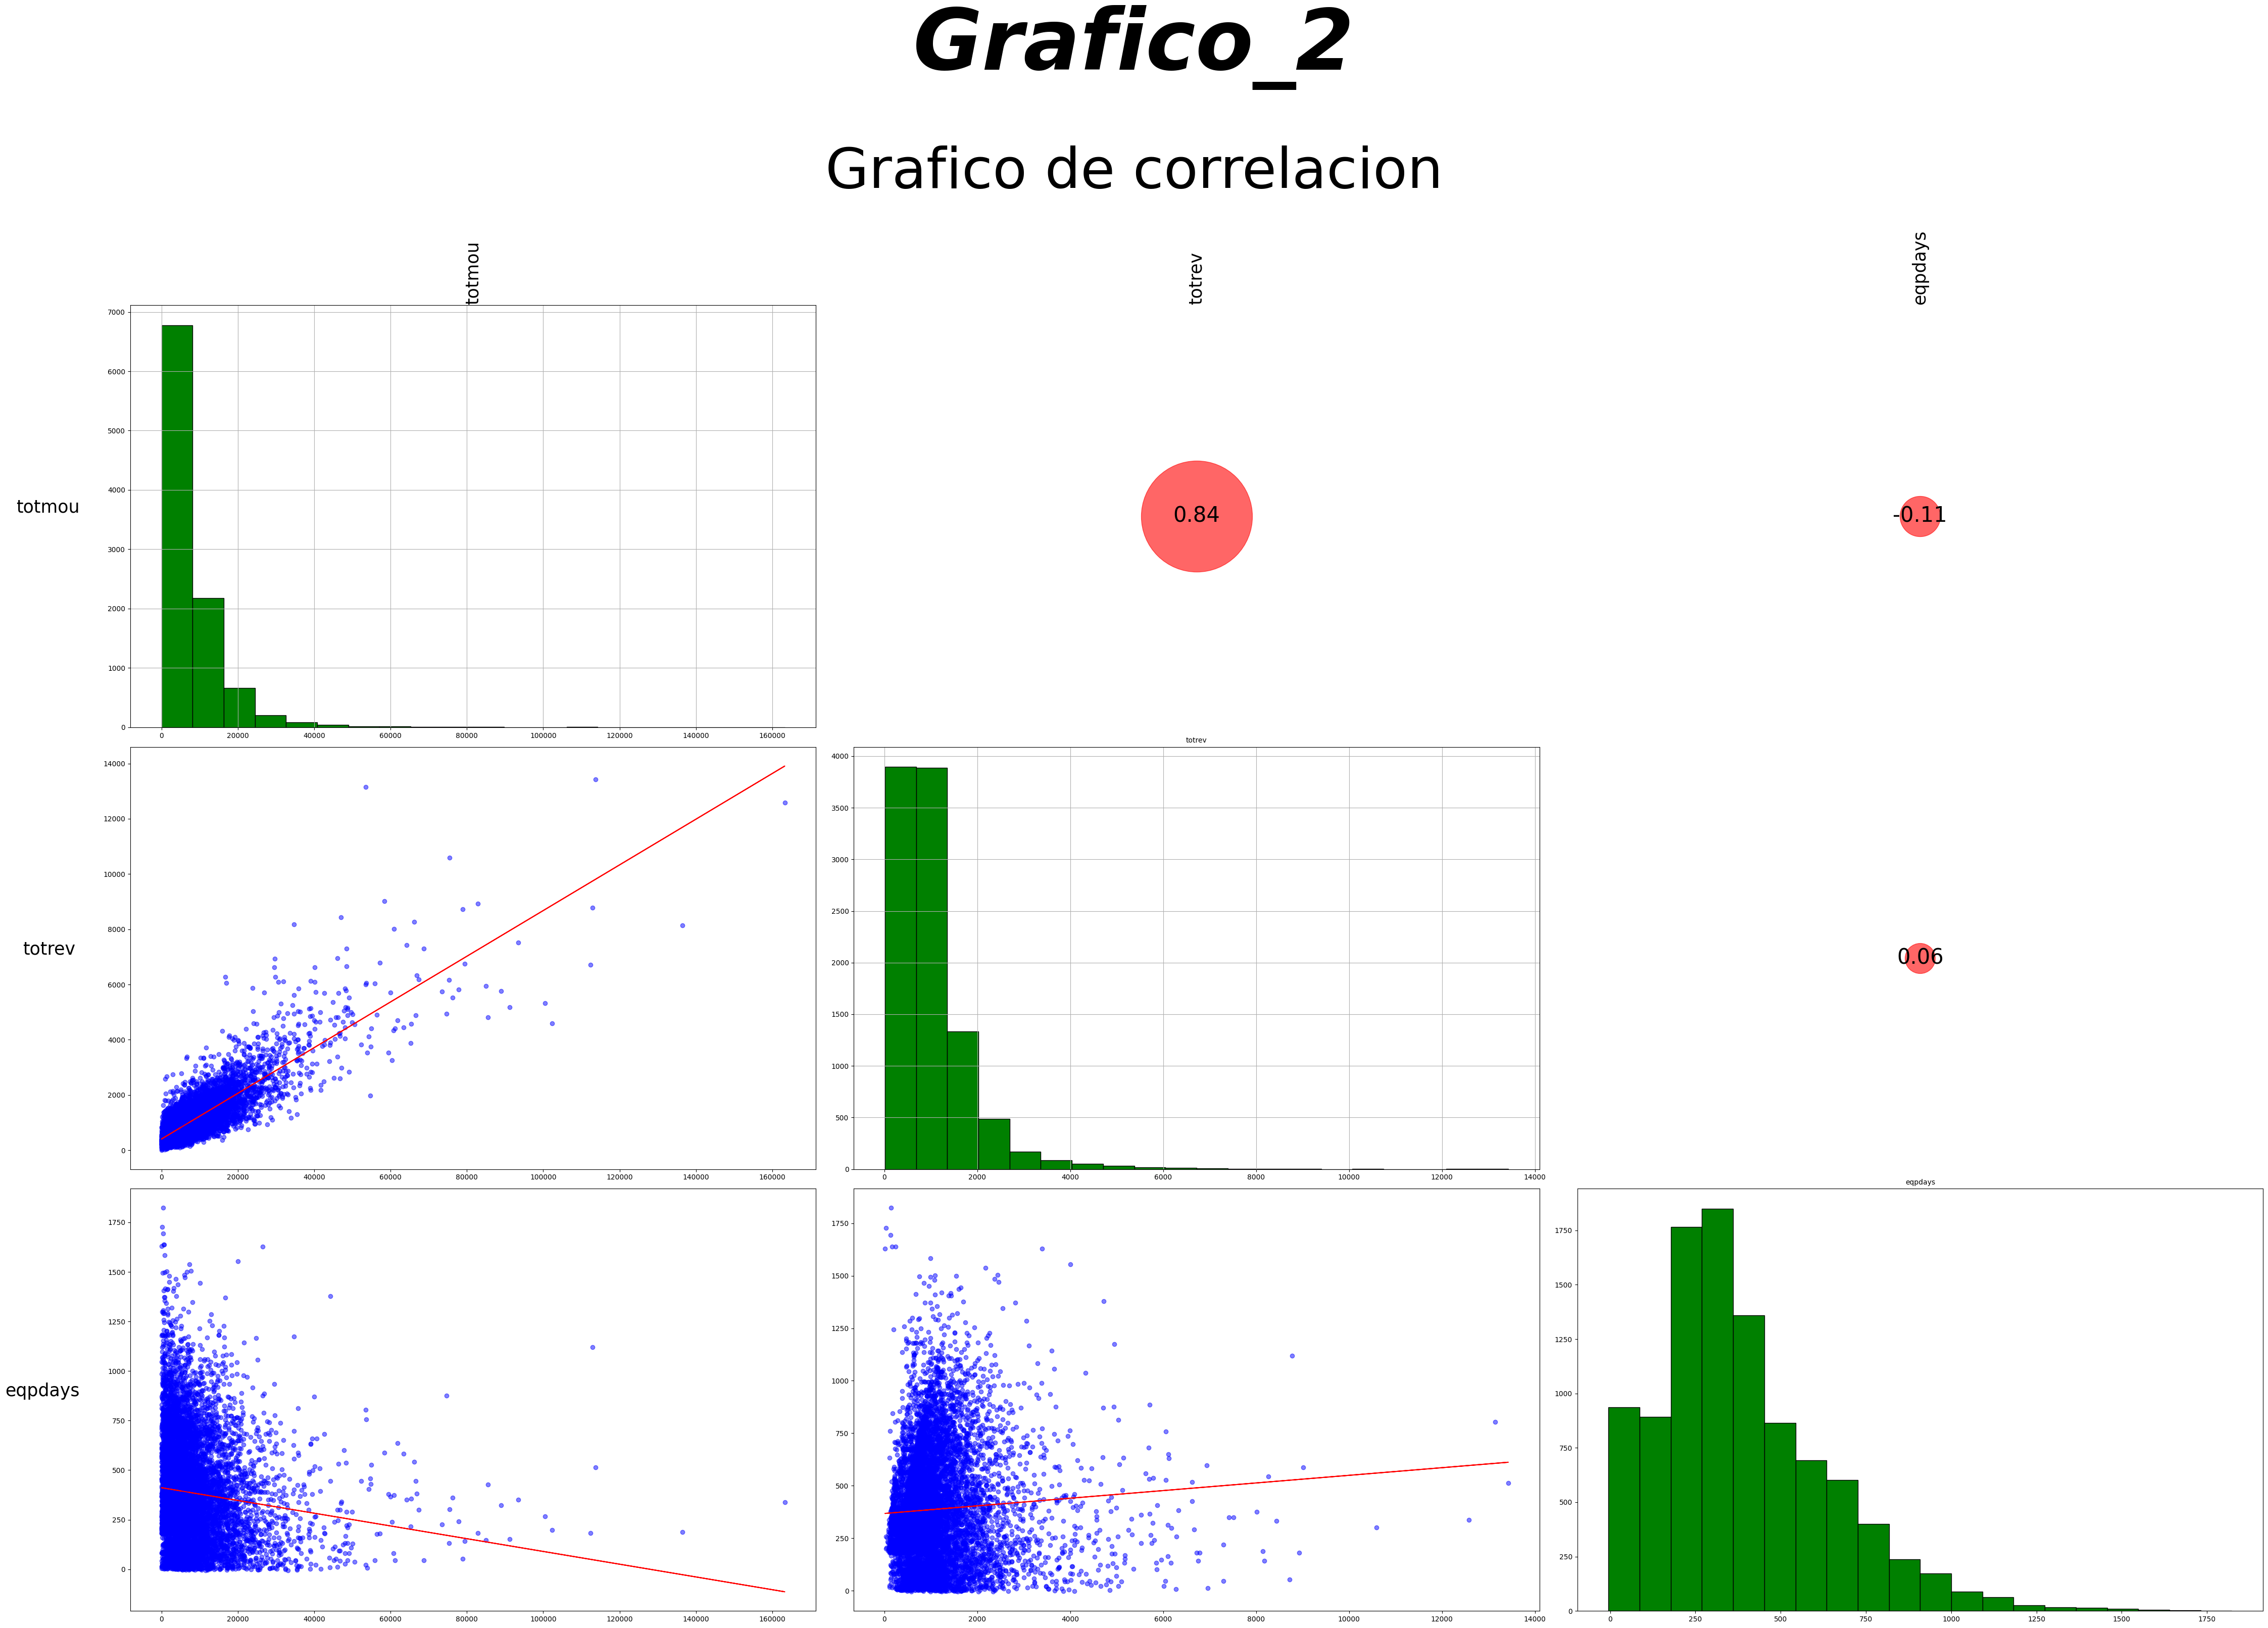

In [13]:
# Llamar a la función con el DataFrame
df_corr = df[['totmou','totrev','eqpdays']]
correlation_plot(df_corr,'Grafico de correlacion','Grafico_2')

## Conclusión
### *Grafico_2*
> Los resultados obtenidos del gráfico de correlación muestran una relación significativa y positiva entre las variables totrev (ingresos totales) y totmou (total de minutos utilizados). Esto indica que ambas variables son directamente proporcionales, es decir, a medida que los ingresos del cliente aumentan, también lo hace el uso total de minutos. Este hallazgo sugiere una correlación directa que podría ser clave para comprender el comportamiento de los clientes y desarrollar estrategias orientadas a maximizar su valor.


# Análisis de Correlación entre **totmou** y **totrev**

## Correlación de Pearson

La fórmula de aceleración de Pearson es:

$r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \sum (Y_i - \bar{Y})^2}}$


Dónde:
- $(X_i)$ y $(Y_i)$ son los valores individuales de las variables
- $( ar{X})$ y $( ar{Y})$ son las medias de las variables

### Resultados

- **Coeficiente de ponderación (r):** 0,8355
- **Valor p:** 0.0000e+00

## Interpretación

1. **Coeficiente de calificación:** El coeficiente obtenido es 0,8355. Esto indica que la relación entre **totmou** y **totrev** es positiva y fuerte.
2. **Valor p:** El valor p obtenido es 0.0000e+00. Dado que es menor que 0.05, podemos rechazar la hipótesis nula de que no existe evaluación significativa entre las variables.

## Prueba de Hipótesis

- **Hipótesis nula (H₀):** No existe evaluación significativa entre **totmou** y **totrev** (\(r = 0\)).
- **Hipótesis alternativa (H₁):** Existe una evaluación significativa entre **totmou** y **totrev** (\(r
ecuación 0\)).

### Conclusión

Dado que el valor p es menor que 0.05, rechazamos la hipótesis nula. Por lo tanto, podemos concluir que existe una evaluación estadísticamente significativa entre las variables **totmou** y **totrev**.

## Aplicabilidad a un Modelo Lineal

Dado que el coeficiente de evaluación es alto y significativo, es probable que un modelo lineal pueda capturar bien la relación entre estas variables, aunque se recomienda realizar un análisis de residuos y validar el modelo con otros indicadores, como el R² , para asegurar su idoneidad


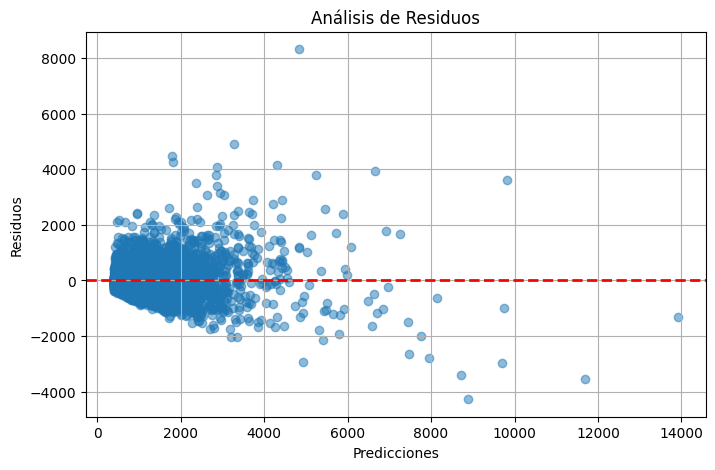

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 totrev   R-squared:                       0.698
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                 2.311e+04
Date:                Wed, 23 Oct 2024   Prob (F-statistic):               0.00
Time:                        02:24:35   Log-Likelihood:                -75738.
No. Observations:               10000   AIC:                         1.515e+05
Df Residuals:                    9998   BIC:                         1.515e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        405.8305      6.301     64.405      0.000     393.479     418.182
totmou         0.0827      0.001    152.025      0.000       0.082       0.084
==============================================================================
Omnibus:                     5006.586   Durbin-Watson:                   2.012
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           176282.350
Skew:                           1.764   Prob(JB):                         0.00
Kurtosis:                      23.264   Cond. No.                     1.55e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.55e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [14]:
# Definir las variables dependiente e independiente
X = df['totmou']
y = df['totrev']

# Agregar una constante para el término independiente en la regresión
X = sm.add_constant(X)

# Ajustar el modelo de regresión lineal
model = sm.OLS(y, X).fit()

# Realizar predicciones
predictions = model.predict(X)

# Análisis de residuos
residuals = y - predictions

# Mostrar el resumen del modelo
model_summary = model.summary()

# Gráfico de residuos
plt.figure(figsize=(8, 5))
plt.scatter(predictions, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Análisis de Residuos')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.grid()
plt.show()

model_summary


# Resultados del Modelo de Regresión Lineal

| **Parámetro**                  | **Valor**                |
|--------------------------------|--------------------------|
| **Variable Dependiente**       | totrev                   |
| **R² (Coeficiente de Determinación)** | 0.698             |
| **R² Ajustado**                | 0.698                    |
| **Método**                     | Mínimos Cuadrados Ordinarios (OLS) |
| **Número de Observaciones**    | 10,000                   |
| **Grados de Libertad (Residual)** | 9,998                |
| **Grados de Libertad (Modelo)** | 1                       |
| **AIC**                        | 151,500                  |
| **BIC**                        | 151,500                  |
| **Log-Likelihood**             | -75,738                  |
| **F-Estadístico**              | 23,110                   |
| **Probabilidad (F-Estadístico)** | 0.000                  |
| **Durbin-Watson**              | 2.012                    |

## Coeficientes del Modelo

| **Variable** | **Coeficiente** | **Error Estándar** | **Estadístico t** | **P>t** | **[0.025** | **0.975]** |
|--------------|-----------------|--------------------|------------------|---------|------------|------------|
| Constante    | 405.8308        | 6.301              | 64.405           | 0.000   | 393.479    | 418.183    |
| totmou       | 0.0827          | 0.001              | 152.025          | 0.000   | 0.082      | 0.084      |


## Pruebas Adicionales

| **Prueba**          | **Valor**         |
|---------------------|-------------------|
| **Omnibus**         | 5006.586          |
| **Prob(Omnibus)**   | 0.000             |
| **Jarque-Bera (JB)**| 176,283.068       |
| **Prob(JB)**        | 0.000             |
| **Asimetría (Skew)**| 1.764             |
| **Curtosis**        | 23.264            |
| **Condición Numérica** | 15,500          |

## Interpretación

1. **R² y R² Ajustado:** El modelo explica aproximadamente **69.8%** de la variabilidad de la variable dependiente (**totrev**) mediante la variable independiente (**totmou**).
   
2. **Coeficiente de totmou:** Por cada unidad adicional en **totmou**, se espera que **totrev** aumente en **0.0827** unidades en promedio.

3. **Significancia:** Dado que el p-valor asociado al coeficiente es **0.000**, es estadísticamente significativo (menor a 0.05).

4. **F-Estadístico:** La probabilidad asociada al F-Estadístico es **0.000**, lo que indica que el modelo en su conjunto es significativo.

5. **Durbin-Watson:** Con un valor de **2.012**, no se detecta autocorrelación significativa entre los residuos.

6. **Omnibus y Jarque-Bera:** Los resultados sugieren que los residuos no siguen una distribución normal, por lo que sería conveniente analizar esto más a fondo.

## Conclusión

El modelo es adecuado para capturar la relación entre **totmou** y **totrev**, ya que presenta un **R²** alto y los coeficientes son significativos. Sin embargo, el análisis de residuos sugiere que podría haber patrones adicionales no capturados por el modelo, lo que implica que podría ser útil explorar otras variables o realizar transformaciones adicionales para mejorar la precisión del modelo.


# El hecho de tener crédito afecta alguna de estas dos variables

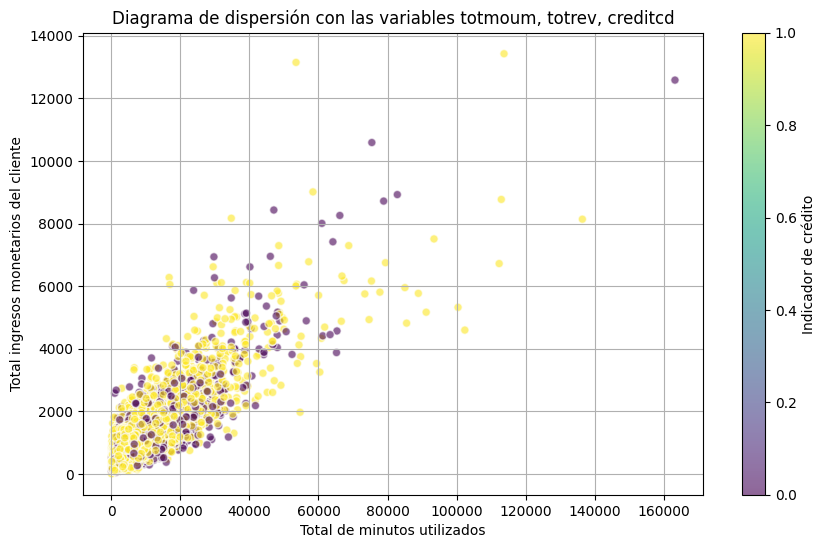

In [15]:
df['creditcd'] = df['creditcd'].map({'N': 0, 'Y': 1})
# Usar el tamaño de los puntos para representar la tercera variable
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['totmou'],df['totrev'], c=df['creditcd'], cmap='viridis', alpha=0.6, edgecolor='w')
plt.colorbar(scatter, label='Indicador de crédito')

# Etiquetas de los ejes
plt.xlabel('Total de minutos utilizados')
plt.ylabel('Total ingresos monetarios del cliente')
plt.title('Diagrama de dispersión con las variables totmoum, totrev, creditcd')
plt.grid()
plt.show()

In [16]:
# Verificar y mostrar los valores únicos en 'creditcd'
print("Valores únicos en 'creditcd':", df['creditcd'].unique())

# Verificar si hay valores nulos después del mapeo
print("Valores nulos en 'creditcd':", df['creditcd'].isnull().sum())

# Filtrar los datos para evitar errores con NaN
df_filtered = df.dropna(subset=['creditcd', 'totmou', 'totrev'])

# Calcular las medias agrupadas por 'creditcd'
credit_analysis = df_filtered.groupby('creditcd')[['totmou', 'totrev']].mean()

# Realizar las pruebas t de Student
t_stat_totmou, p_value_totmou = ttest_ind(
    df_filtered[df_filtered['creditcd'] == 1]['totmou'],
    df_filtered[df_filtered['creditcd'] == 0]['totmou'],
    nan_policy='omit'
)

t_stat_totrev, p_value_totrev = ttest_ind(
    df_filtered[df_filtered['creditcd'] == 1]['totrev'],
    df_filtered[df_filtered['creditcd'] == 0]['totrev'],
    nan_policy='omit'
)

# Mostrar los resultados
print("\nMedias agrupadas por 'creditcd':")
print(credit_analysis)

print("\nPrueba t para 'totmou':")
print(f"Estadístico t: {t_stat_totmou:.4f}, Valor p: {p_value_totmou:.4e}")

print("\nPrueba t para 'totrev':")
print(f"Estadístico t: {t_stat_totrev:.4f}, Valor p: {p_value_totrev:.4e}")


Valores únicos en 'creditcd': [1, 0, NaN]
Categories (2, int64): [0, 1]
Valores nulos en 'creditcd': 152

Medias agrupadas por 'creditcd':
               totmou       totrev
creditcd                          
0         8288.587484  1035.948303
1         7432.628016  1045.155534

Prueba t para 'totmou':
Estadístico t: -4.5395, Valor p: 5.7047e-06

Prueba t para 'totrev':
Estadístico t: 0.4925, Valor p: 6.2238e-01


<ipython-input-16-285a6a57b0bd>:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_analysis = df_filtered.groupby('creditcd')[['totmou', 'totrev']].mean()


# Análisis del Efecto del Crédito en las Variables **totmou** y **totrev**

## Datos Explorados

- **Valores únicos en 'creditcd'**: [1, 0, NaN]
  - **1**: Tiene crédito.
  - **0**: No tiene crédito.
- **Valores nulos en 'creditcd'**: 152

## Medias Agrupadas por Crédito

| **Crédito (creditcd)** | **Media totmou** | **Media totrev** |
|------------------------|------------------|------------------|
| No (0)                 | 8288.59          | 1035.95          |
| Sí (1)                 | 7432.63          | 1045.16          |

## Resultados de la Prueba t de Student

### Comparación de **totmou** (Minutos Totales de Uso)
- **Estadístico t**: -4.5395  
- **Valor p**: 5.7047e-06  
- **Interpretación**: Dado que el valor p es menor que 0.05, podemos **rechazar la hipótesis nula**. Esto indica que **existe una diferencia significativa** en los minutos de uso entre los usuarios con y sin crédito. Los usuarios **sin crédito** muestran un uso mayor en promedio (8288.59 minutos) en comparación con los usuarios con crédito (7432.63 minutos).

### Comparación de **totrev** (Ingresos Totales)
- **Estadístico t**: 0.4925  
- **Valor p**: 0.6224  
- **Interpretación**: En este caso, el valor p es mayor que 0.05, por lo que **no podemos rechazar la hipótesis nula**. Esto sugiere que **no existe una diferencia significativa** en los ingresos totales entre los usuarios con y sin crédito.

## Análisis de Valores Nulos
- **Valores nulos en 'creditcd'**: 152  
  Estas observaciones fueron excluidas del análisis ya que no es posible determinar si los usuarios tienen crédito o no. Se recomienda investigar la fuente de estos valores faltantes para asegurar la calidad de los datos.

## Conclusiones

1. **totmou**: El crédito afecta significativamente los minutos de uso total. Los usuarios sin crédito tienden a utilizar más minutos en comparación con aquellos con crédito. Esto podría indicar que los usuarios sin acceso a crédito recurren a otros medios de comunicación o hacen un uso más intensivo de los servicios disponibles.

2. **totrev**: No se encontró evidencia significativa de que el crédito afecte los ingresos totales. Esto sugiere que el comportamiento en términos de ingresos es similar entre ambos grupos, independientemente de si tienen crédito o no.

3. **Valores nulos**: La presencia de valores nulos en la columna `'creditcd'` debe ser investigada, ya que puede afectar la interpretación de los resultados.

## Recomendaciones

- **Investigación adicional**: Explorar por qué los usuarios sin crédito tienen un mayor tiempo de uso puede ayudar a identificar patrones de comportamiento interesantes.
- **Tratamiento de valores nulos**: Considerar la imputación o la recolección de información adicional para las observaciones faltantes.
- **Análisis complementario**: Realizar análisis adicionales, como modelos multivariados, para comprender mejor las diferencias entre los grupos y el impacto de otras variables en los ingresos y el uso total.

---


#### Conclusión:
No se evidencia una afectación sobre las variables con el hecho de tener o no credito.